In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('./placement (2).csv')


In [4]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package in lpa')

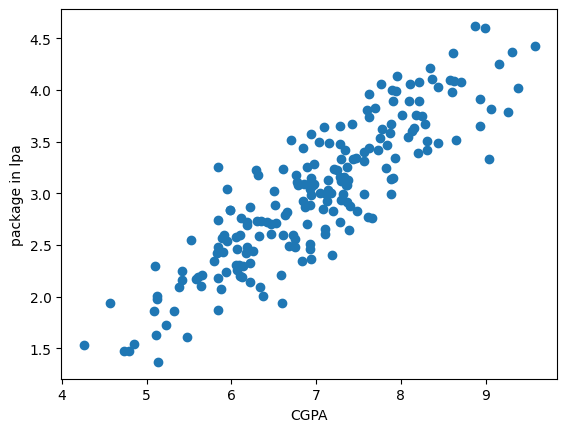

In [5]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('package in lpa')

In [6]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [10]:
lr.predict(X_test.iloc[9].values.reshape(1,1))

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.4923915])

Text(0, 0.5, 'package in lpa')

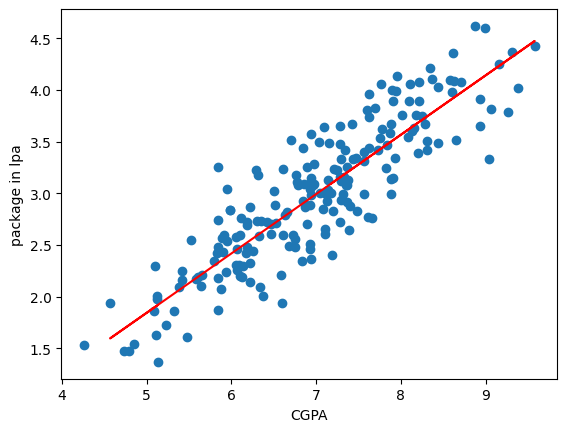

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('package in lpa')


In [12]:
m=lr.coef_

In [13]:
b=lr.intercept_

In [16]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print('R2 Score:',r2_score(y_test,lr.predict(X_test)))
print('Mean Squared Error:',np.sqrt(mean_squared_error(y_test,lr.predict(X_test))))
print('Mean Absolute Error:',mean_absolute_error(y_test,lr.predict(X_test)))

R2 Score: 0.7730984312051673
Mean Squared Error: 0.2901316659954521
Mean Absolute Error: 0.23150985393278373


In [17]:
r2=r2_score(y_test,lr.predict(X_test))
adj_r2=1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted R2 Score:',adj_r2)

Adjusted R2 Score: 0.7671273372895138


In [24]:
new_df1=df.copy()
new_df1['iq']=new_df1['package']+(np.random.randint(-12,12,200)/10)
new_df1=new_df1[['cgpa','iq','package']]
new_df1.head()


,cgpa,iq,package
0,6.89,2.66,3.26
1,5.12,2.08,1.98
2,7.82,3.75,3.25
3,7.42,3.27,3.67
4,6.94,4.37,3.57


In [27]:
X1=new_df1.iloc[:,0:2]
y1=new_df1.iloc[:,-1]
X1_train,X1_test,y1_train,y1_test=train_test_split(X1,y1,test_size=0.2,random_state=42)
lr1=LinearRegression()
lr1.fit(X1_train,y1_train)
y_pred=lr1.predict(X1_test)
print('R2 Score:',r2_score(y1_test,y_pred))
r2=r2_score(y1_test,y_pred)
adj_r2=1-(1-r2)*(len(y1_test)-1)/(len(y1_test)-X1_test.shape[1]-1)
print('Adjusted R2 Score:',adj_r2)

R2 Score: 0.8147493566773546
Adjusted R2 Score: 0.8047358083896441
